# Montréal Gas Price — Daily Dataset Build
**Sources:**
- Gas prices: Kalibrate xlsx files (2016–2026), city = MONTRÉAL
- WTI crude oil: FRED series `DCOILWTICO` (USD/barrel, daily)
- CAD/USD rate: FRED series `DEXCAUS` (USD per 1 CAD, daily)

**Output:** `montreal_gas_features_daily.csv` — merged daily dataset ready for ML

## 0. Install & import

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn fredapi openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from fredapi import Fred

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
print('Ready.')

Ready.


## 1. Parse Kalibrate xlsx files → daily Montréal gas prices

In [3]:
DATA_DIR = './Data'
YEARS = range(2016, 2027)
CITY = 'MONTR'

def parse_all_years(years):
    '''
    Function: reads the data (excel format) of the year of input, and returns a
    dataframe of the that year's dataset.

    Input: year (int)
    Output: dataframe of Montreal gasoline prices from 2016/07/01 to 2026/03/30
    '''
    records = []
    prev_date = None
    prev_prices = []

    for year in years:
        path = f'{DATA_DIR}/Daily{year}.xlsx'
        raw  = pd.read_excel(path, header=None)
    
        # Since some year's layout differ, methodology of parsing informations also differs.
        if year == 2016:
            # 2016 layout: dates in row 0, cities from row 1
            date_row = raw.iloc[0, 1:].values # Row 0, col 1+ = Dates row
            df_raw = raw.iloc[1:, :].set_index(0) # Row 1+, col 0 = Data (prices) entries
        else:
            # 2017–2026 layout: dates in row 2, cities from row 3
            date_row = raw.iloc[2, 1:].values
            df_raw = raw.iloc[3:, :].set_index(0)
    
        # Indexing Montreal gasoline price data
        montreal_row = df_raw[df_raw.index.str.contains(CITY, na= False, case = False)] # so it doesn't compare with non-boolean types such as NaN
        prices = montreal_row.iloc[0].values
        
        for d, p in zip(date_row, prices):
            # edge case: date is missing
            try:
                current_date = pd.to_datetime(f'{d}/{year}', format = '%m/%d/%Y')
            except Exception:
                if prev_date is None:
                    continue
                current_date = prev_date + pd.Timedelta(days=1)
            
            # edge case: price is missing
            if pd.isna(p):
                if len(prev_prices) == 0:
                    continue
                current_price = float(np.mean(prev_prices))
            else:
                current_price = float(p)
    
            # Appending data in records list
            records.append({'date': current_date, 'gas_price': current_price})
            
            prev_date = current_date
            prev_prices.append(current_price) 
            if len(prev_prices) > 5:
                prev_prices.pop(0)
        print(f'gasoline prices in year {year} is now added')
    return pd.DataFrame(records)

gas = (
    parse_all_years(YEARS)
    .sort_values('date')
    .drop_duplicates(subset='date', keep='last')
    .set_index('date')
    .sort_index()
)

# Reindex to full business-day calendar and forward-fill short gaps (holidays)
full_idx = pd.bdate_range(gas.index.min(), min(gas.index.max(), pd.Timestamp.today()))
gas = gas.reindex(full_idx)
gas.index.name = 'date'
gas['gas_price'] = gas['gas_price'].ffill(limit=5)

print(f'\nGas price series: {len(gas):,} business days  '
      f'{gas.index.min().date()} → {gas.index.max().date()}')
print(f'Missing after ffill: {gas.gas_price.isna().sum()}')

gasoline prices in year 2016 is now added
gasoline prices in year 2017 is now added
gasoline prices in year 2018 is now added
gasoline prices in year 2019 is now added
gasoline prices in year 2020 is now added
gasoline prices in year 2021 is now added
gasoline prices in year 2022 is now added
gasoline prices in year 2023 is now added
gasoline prices in year 2024 is now added
gasoline prices in year 2025 is now added
gasoline prices in year 2026 is now added

Gas price series: 2,545 business days  2016-07-01 → 2026-04-02
Missing after ffill: 0


In [4]:
gas

,gas_price
date,
2016-07-01,117.900
2016-07-04,110.500
2016-07-05,109.300
2016-07-06,108.200
2016-07-07,107.100
...,...
2026-03-27,182.900
2026-03-30,192.700
2026-03-31,193.100


## 2. Fetch WTI crude & CAD/USD from FRED (daily)

Crude Oil Prices (WTI): https://fred.stlouisfed.org/series/DCOILWTICO

CAD/USD Dollar Spot Exchange Rate: https://fred.stlouisfed.org/series/DEXCAUS#

In [5]:
wti = pd.read_csv('./Data/DCOILWTICO.csv').head()
wti

,observation_date,DCOILWTICO
0,2016-07-01,49.02
1,2016-07-04,NaN
2,2016-07-05,46.73
3,2016-07-06,47.37
4,2016-07-07,45.22


In [6]:
fx = pd.read_csv('./Data/DEXCAUS.csv').head()
fx

,observation_date,DEXCAUS
0,2016-07-01,1.2897
1,2016-07-04,NaN
2,2016-07-05,1.2950
3,2016-07-06,1.3003
4,2016-07-07,1.2984


In [7]:
START_DATE   = '2016-07-01'

# WTI crude oil spot price — daily, USD per barrel
wti = pd.read_csv(
    './Data/DCOILWTICO.csv',
    parse_dates = ['observation_date'],
    index_col = 'observation_date'
).rename(columns = {'DCOILWTICO': 'wti_usd'})
wti.index.name = 'date'
wti = wti[wti.index >= START_DATE]
print(f'WTI  : {len(wti):,} rows  {wti.index.min().date()} → {wti.index.max().date()}')

# CAD/USD exchange rate — daily, USD per 1 CAD
fx = pd.read_csv(
    './Data/DEXCAUS.csv',
    parse_dates = ['observation_date'],
    index_col = 'observation_date'
).rename(columns = {'DEXCAUS': 'cadusd'})
fx.index = pd.to_datetime(fx.index)
fx.index.name = 'date'
fx = fx[fx.index >= START_DATE]
print(f'CADUSD: {len(fx):,} rows  {fx.index.min().date()} → {fx.index.max().date()}')

WTI  : 2,537 rows  2016-07-01 → 2026-03-23
CADUSD: 2,541 rows  2016-07-01 → 2026-03-27


In [8]:
# FRED daily series have weekend/holiday gaps — forward-fill up to 5 days
wti   = wti.reindex(full_idx).ffill(limit=5)
fx    = fx.reindex(full_idx).ffill(limit=5)

print(f'WTI   missing after ffill: {wti.wti_usd.isna().sum()}')
print(f'CADUSD missing after ffill: {fx.cadusd.isna().sum()}')

WTI   missing after ffill: 3
CADUSD missing after ffill: 0


## 3. Merge into one daily DataFrame

In [9]:
# Joining/Merging all data into one dataset/dataframe
df = gas.join(wti).join(fx)

# Adding a feature with WTI Crude Oil price expressed in CAD
# cadusd = USD per CAD, so WTI_CAD = WTI_USD / cadusd
df['wti_cad'] = df['wti_usd'] / df['cadusd']

# Drop rows where any core column is missing
before = len(df)
df.dropna(subset=['gas_price', 'wti_usd', 'cadusd'], inplace=True)
print(f'Dropped {before - len(df)} rows with missing core values')
print(f'Final dataset: {len(df):,} rows  {df.index.min().date()} → {df.index.max().date()}')
df

Dropped 3 rows with missing core values
Final dataset: 2,542 rows  2016-07-01 → 2026-03-30


,gas_price,wti_usd,cadusd,wti_cad
date,,,,
2016-07-01,117.9,49.02,1.2897,38.008839
2016-07-04,110.5,49.02,1.2897,38.008839
2016-07-05,109.3,46.73,1.2950,36.084942
2016-07-06,108.2,47.37,1.3003,36.430055
2016-07-07,107.1,45.22,1.2984,34.827480
...,...,...,...,...
2026-03-24,194.4,89.33,1.3764,64.901192
2026-03-25,181.8,89.33,1.3799,64.736575
2026-03-26,187.3,89.33,1.3849,64.502852


## 4. Data quality check
Checking for any potential data errors or missing data in our dataset after handling them.

In [10]:
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Descriptive stats ===')
df.describe().round(2)

=== Missing values ===
gas_price    0
wti_usd      0
cadusd       0
wti_cad      0
dtype: int64

=== Descriptive stats ===


,gas_price,wti_usd,cadusd,wti_cad
count,2542.00,2542.00,2542.00,2542.00
mean,142.07,65.21,1.33,49.26
std,26.02,17.17,0.05,13.28
min,81.20,-36.98,1.20,-26.29
25%,120.60,53.14,1.29,40.60
50%,141.15,64.82,1.33,48.82
75%,161.30,75.47,1.36,56.86
max,223.20,123.64,1.46,97.37


## 5. Visualize
Provide the final step of Exploratory Data Analysis (EDA) - Visualizing the datas.
1. Regular gasoline prices from 2016/07/01 to 2026/03/30
2. WTI Crude Oil Prices per Barrel from 2016/07/01 to 2026/03/30
3. CAD/USD Exchange rate from 2016/07/01 to 2026/03/30

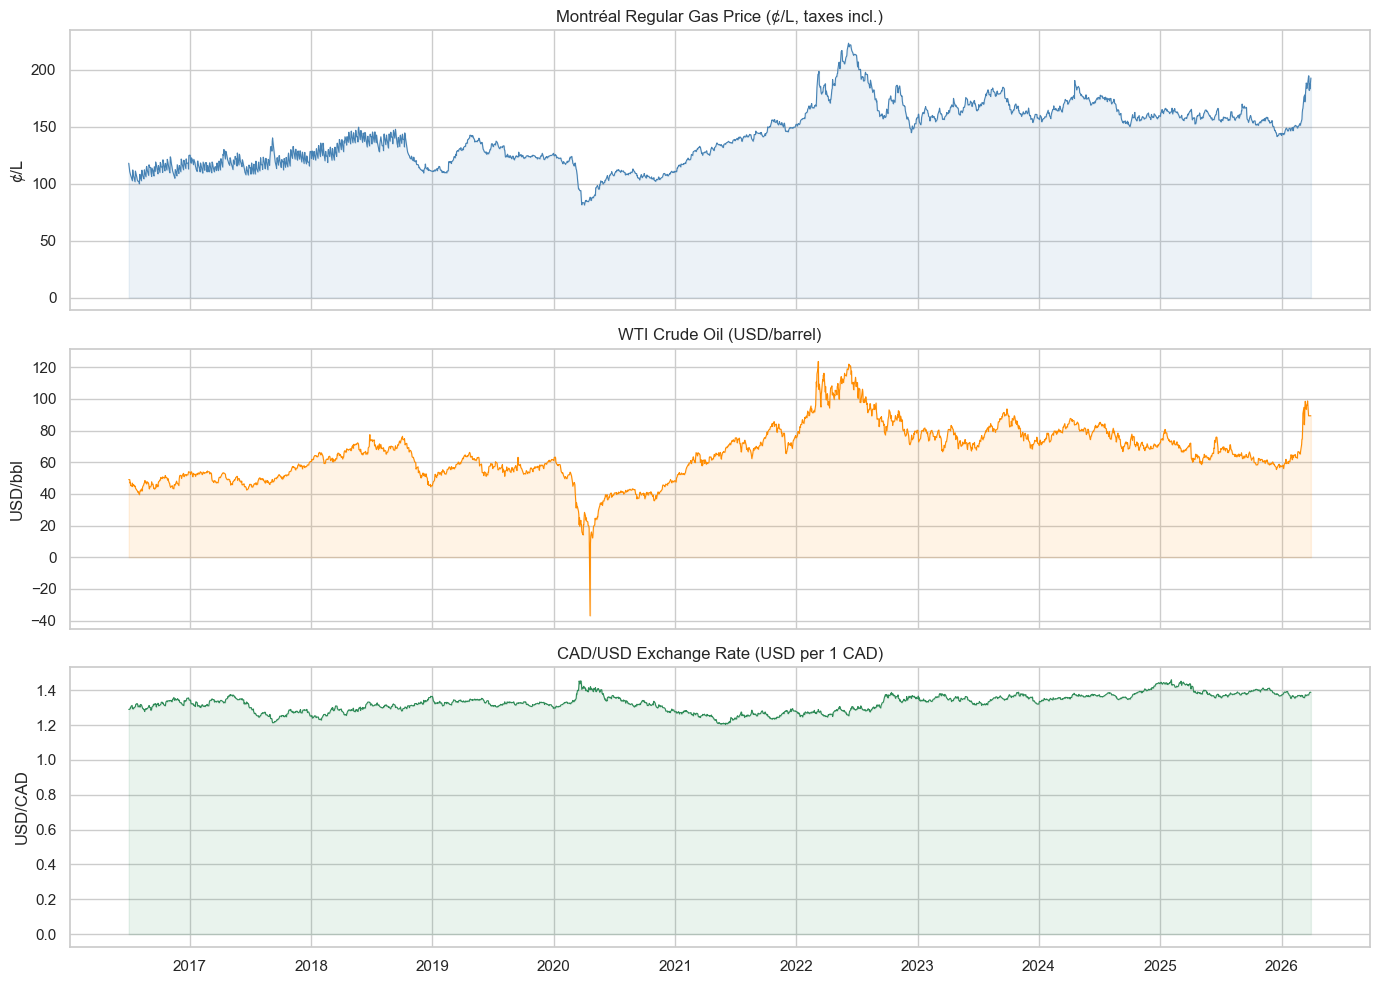

In [11]:
# Configure the plot figure size
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot regular daily gasoline prices
axes[0].plot(df.index, df['gas_price'], color='steelblue', linewidth=0.8)
axes[0].fill_between(df.index, df['gas_price'], alpha=0.1, color='steelblue')
axes[0].set_title('Montréal Regular Gas Price (¢/L, taxes incl.)')
axes[0].set_ylabel('¢/L')

# Plot WTI crude Oil
axes[1].plot(df.index, df['wti_usd'], color='darkorange', linewidth=0.8)
axes[1].fill_between(df.index, df['wti_usd'], alpha=0.1, color='darkorange')
axes[1].set_title('WTI Crude Oil (USD/barrel)')
axes[1].set_ylabel('USD/bbl')

# Plot Cad/Usd Exchange rate
axes[2].plot(df.index, df['cadusd'], color='seagreen', linewidth=0.8)
axes[2].fill_between(df.index, df['cadusd'], alpha=0.1, color='seagreen')
axes[2].set_title('CAD/USD Exchange Rate (USD per 1 CAD)')
axes[2].set_ylabel('USD/CAD')

# Set all plots on the same x-axis scale (time)
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()

# Save all plots to a file
plt.savefig('daily_series_overview.png', dpi=150)
plt.show()

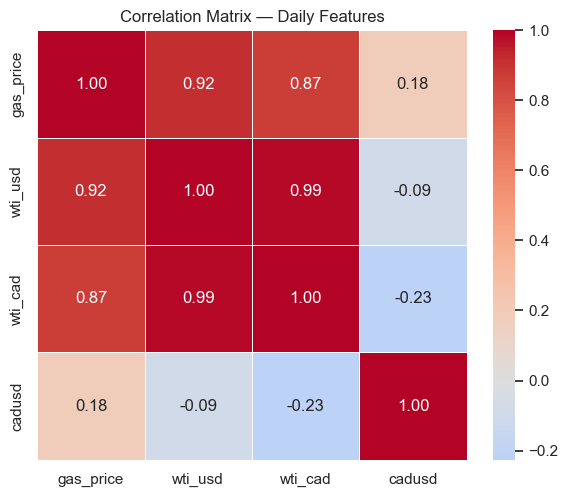

In [12]:
# Correlation heatmap
corr = df[['gas_price', 'wti_usd', 'wti_cad', 'cadusd']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Daily Features')
plt.tight_layout()
plt.show()

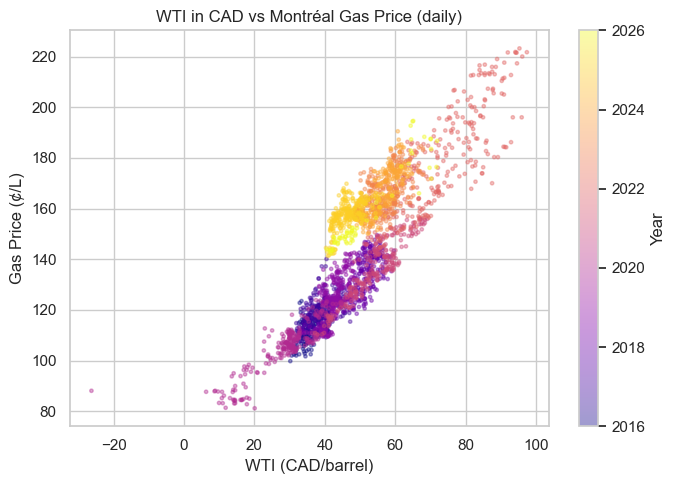

In [13]:
# Scatter: WTI (CAD) vs gas price — coloured by year
fig, ax = plt.subplots(figsize=(7, 5))
years = df.index.year
scatter = ax.scatter(df['wti_cad'], df['gas_price'],
                     c=years, cmap='plasma', alpha=0.4, s=6)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_xlabel('WTI (CAD/barrel)')
ax.set_ylabel('Gas Price (¢/L)')
ax.set_title('WTI in CAD vs Montréal Gas Price (daily)')
plt.tight_layout()
plt.show()

## 6. Save

In [14]:
df.to_csv('montreal_gas_features_daily.csv')
print(f'Saved: montreal_gas_features_daily.csv  ({len(df):,} rows x {df.shape[1]} columns)')
print('Columns:', df.columns.tolist())

Saved: montreal_gas_features_daily.csv  (2,542 rows x 4 columns)
Columns: ['gas_price', 'wti_usd', 'cadusd', 'wti_cad']


## 7. What's in the dataset

| Column | Description |
|---|---|
| `gas_price` | Montréal retail regular gas, ¢/L, taxes included |
| `wti_usd` | WTI crude oil spot price, USD/barrel |
| `cadusd` | Exchange rate: USD per 1 CAD |
| `wti_cad` | WTI expressed in CAD/barrel (= wti_usd / cadusd) |

## Next step: feature engineering

With this clean daily base, the next notebook will add:
- **Lag features** — `gas_price` at t-1, t-2, t-5, t-10, t-21
- **Rolling stats** — 5-day and 21-day rolling mean and std of gas price and WTI
- **WTI momentum** — 1-day, 5-day change in WTI
- **Calendar features** — day of week, month, is_month_end
- **Target variable** — next-day gas price (or next-day price change)